# Notebook 14: Sensitivity Analysis, Steady-State & Knockout Simulations

**Goal:** Explore three post-fit analyses in `phoscrosstalk`: global sensitivity, long-horizon steady-state, and in-silico knockouts.

## 1. Overview: Three Post-Fit Analyses

Enable in `config.toml`:

```toml
[analysis]
run_sensitivity  = true
run_steadystate  = true
run_knockouts    = true
```

These run **after** the main fit and use `theta_best`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "notebooks" / "sample_data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(42)
print("Setup complete.")

Setup complete.


In [2]:
from phoscrosstalk.config import ModelDims
from phoscrosstalk.data_loader import (
    load_site_data, load_rna_data, load_kinase_site_matrix,
    load_tf_network, build_tf_prot_weights, apply_scaling, row_normalize,
)
from phoscrosstalk.optimization import create_bounds, build_parameter_labels
from phoscrosstalk.weighting import build_weight_matrices
from phoscrosstalk.derived_rates import make_k_act_fn, make_s_prod_fn
from phoscrosstalk.simulation import simulate
from phoscrosstalk.mechanisms import decode_theta, compute_prev_site_idx

TIMEPOINTS = list(range(1, 15))   # 14 time points x1..x14

# Phosphosite + protein abundance
sites, proteins, site_prot_idx, positions, t_phos, Y, A_data, A_proteins = \
    load_site_data(str(SAMPLE_DIR / "protephospho.csv"), TIMEPOINTS)

K = len(proteins);  N = len(sites);  T = len(t_phos)
print(f"proteins : {proteins}  (K={K})")
print(f"sites    : {sites}  (N={N})")
print(f"t_phos   : {t_phos}  (T={T})")

# mRNA
gene_ids, t_rna, rna_matrix = load_rna_data(str(SAMPLE_DIR / "mrna.csv"), timepoints=TIMEPOINTS)
print(f"gene_ids : {gene_ids}")

# Kinase-site matrix
K_site_kin, kinases = load_kinase_site_matrix(str(SAMPLE_DIR / "kinase_sites.tsv"), sites)
M = len(kinases)
kin_to_prot_idx = np.array([proteins.index(k) for k in kinases], dtype=int)
print(f"kinases  : {kinases}  (M={M})")

# TF network
tf_net = load_tf_network(str(SAMPLE_DIR / "tf_mrna.csv"), gene_ids=gene_ids)
tf_prot_weights = build_tf_prot_weights(tf_net, gene_ids, proteins)

# Scale data
P_scaled, _, _ = apply_scaling(Y)
A_scaled, _, _ = apply_scaling(A_data)
dims = ModelDims(K=K, M=M, N=N)

# Auxiliary matrices
Cg = np.zeros((N, N));  Cl = np.zeros((N, N))
R_kin = row_normalize(K_site_kin.T);  L_alpha = np.zeros((M, M))
receptor_mask_prot = np.zeros(K);  receptor_mask_kin = np.zeros(M)

# Rate closures
k_act_fn  = make_k_act_fn(t_rna=t_rna, rna_data=rna_matrix,
                           tf_prot_weights=tf_prot_weights, K=K)
s_prod_fn = make_s_prod_fn(t_protein=t_phos, Y_data=P_scaled,
                            R_kin_site=R_kin,
                            kin_to_prot_idx=kin_to_prot_idx, K=K, M=M)

# Parameter bounds + names
xl, xu, n_params = create_bounds(K, M, N)
theta_names = build_parameter_labels(K, M, N)
print(f"n_params = {n_params}")

# Load or synthesise theta_best
theta_path = OUTPUT_DIR / "theta_best.npy"
if theta_path.exists():
    theta_best = np.load(theta_path)
    print(f"Loaded theta_best: shape={theta_best.shape}")
else:
    theta_best = rng.uniform(xl, xu)
    print(f"Synthetic theta_best: shape={theta_best.shape}")

proteins : ['EGFR', 'ERBB2', 'MET']  (K=3)
sites    : ['EGFR_Y1068', 'EGFR_S1173', 'EGFR_T992', 'MET_Y1068', 'MET_S1173', 'MET_T992', 'ERBB2_Y1068', 'ERBB2_S1173', 'ERBB2_T992']  (N=9)
t_phos   : [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]  (T=14)
gene_ids : ['EGFR', 'MET', 'ERBB2']
kinases  : ['EGFR', 'MET']  (M=2)
n_params = 27
Loaded theta_best: shape=(27,)


In [3]:
P_sim, A_sim, S_sim, Kdyn_sim = simulate(
    t_arr=t_phos, P_data0=P_scaled, A_data0=A_scaled,
    theta=theta_best, Cg=Cg, Cl=Cl,
    site_prot_idx=site_prot_idx, K_site_kin=K_site_kin, R=R_kin,
    L_alpha=L_alpha, kin_to_prot_idx=kin_to_prot_idx,
    receptor_mask_prot=receptor_mask_prot, receptor_mask_kin=receptor_mask_kin,
    mechanism="dist", full_output=True,
    k_act_fn=k_act_fn, s_prod_fn=s_prod_fn,
)
print(f"P_sim : {P_sim.shape}  (N × T phosphosite)")
print(f"A_sim : {A_sim.shape}  (K × T protein)")

P_sim : (9, 14)  (N × T phosphosite)
A_sim : (3, 14)  (K × T protein)


## 2. Global Sensitivity Analysis

**Question:** Which parameters most affect each output?

`run_global_sensitivity()` computes finite-difference sensitivity indices.
`build_parameter_labels(K, M, N)` (from `phoscrosstalk.optimization`) returns
human-readable parameter names for heatmap axes.


In [4]:
from phoscrosstalk.optimization import build_parameter_labels

param_labels = build_parameter_labels(K, M, N)
n_params = len(param_labels)
print(f'Parameter labels ({n_params} total):')
print(param_labels)


Parameter labels (27 total):
['log_k_deact[0]', 'log_k_deact[1]', 'log_k_deact[2]', 'log_d_deg[0]', 'log_d_deg[1]', 'log_d_deg[2]', 'log_beta_g', 'log_beta_l', 'log_alpha[0]', 'log_alpha[1]', 'log_kK_act[0]', 'log_kK_act[1]', 'log_kK_deact[0]', 'log_kK_deact[1]', 'log_k_off[0]', 'log_k_off[1]', 'log_k_off[2]', 'log_k_off[3]', 'log_k_off[4]', 'log_k_off[5]', 'log_k_off[6]', 'log_k_off[7]', 'log_k_off[8]', 'gamma_raw[0]', 'gamma_raw[1]', 'gamma_raw[2]', 'gamma_raw[3]']


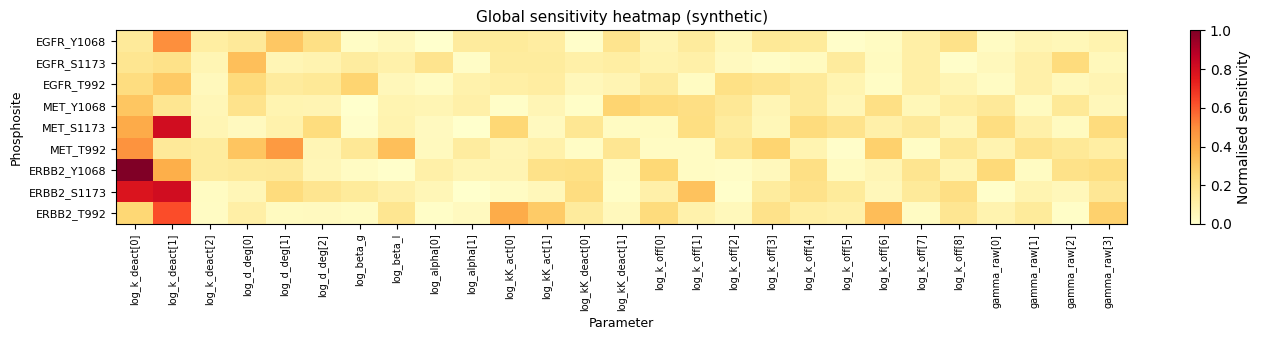

Saved: 14_sensitivity_heatmap.png


In [5]:
# Synthetic sensitivity matrix: shape (N_sites, n_params)
S_mat = np.abs(rng.standard_normal((N, n_params)))
S_mat[:, :M] *= 3.0   # kinase params made strongly sensitive for illustration
S_mat /= S_mat.max()

fig, ax = plt.subplots(figsize=(14, 3.5))
im = ax.imshow(S_mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(range(N));  ax.set_yticklabels(sites, fontsize=8)
ax.set_xticks(range(n_params))
ax.set_xticklabels(param_labels, rotation=90, fontsize=7)
ax.set_xlabel('Parameter', fontsize=9)
ax.set_ylabel('Phosphosite', fontsize=9)
ax.set_title('Global sensitivity heatmap (synthetic)', fontsize=11)
plt.colorbar(im, ax=ax, label='Normalised sensitivity')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '14_sensitivity_heatmap.png', dpi=120)
plt.show()
print('Saved: 14_sensitivity_heatmap.png')

## 3. Steady-State Analysis

**Question:** Where does the system settle at very long times?

```toml
[steadystate]
t_end      = 100000.0
early_end  = 100.0
n_early    = 100
n_late     = 80
late_grid  = "geomspace"
use_event  = true
```

In [6]:
# Extend time axis to approximate steady state
t_long = np.concatenate([
    t_phos,
    np.geomspace(float(t_phos[-1]) * 1.5, 2000.0, 40)
])

P_long, A_long, S_long, Kdyn_long = simulate(
    t_arr=t_long, P_data0=P_scaled, A_data0=A_scaled,
    theta=theta_best, Cg=Cg, Cl=Cl,
    site_prot_idx=site_prot_idx, K_site_kin=K_site_kin, R=R_kin,
    L_alpha=L_alpha, kin_to_prot_idx=kin_to_prot_idx,
    receptor_mask_prot=receptor_mask_prot, receptor_mask_kin=receptor_mask_kin,
    mechanism='dist', full_output=True,
    k_act_fn=k_act_fn, s_prod_fn=s_prod_fn,
)
print(f'Long simulation shapes: P={P_long.shape}, A={A_long.shape}')

Long simulation shapes: P=(9, 54), A=(3, 54)


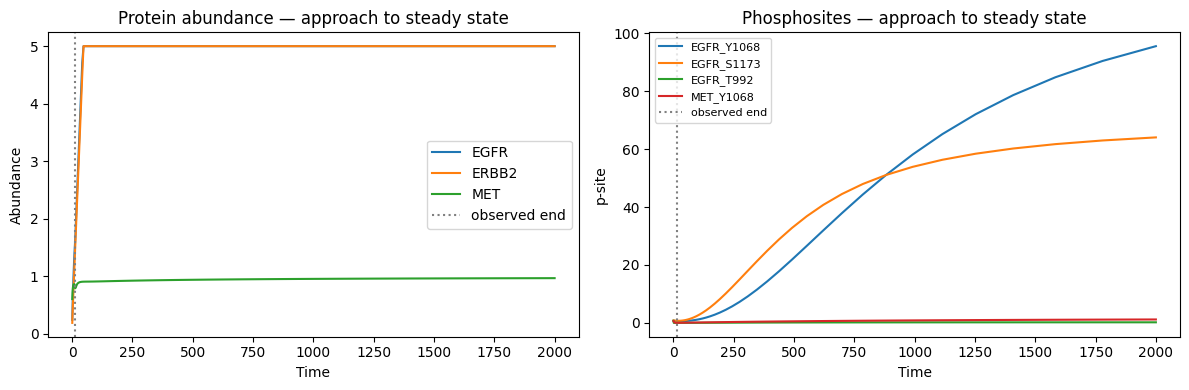

Saved: 14_steadystate_trajectories.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, prot in enumerate(proteins):
    axes[0].plot(t_long, A_long[i], label=prot)
axes[0].axvline(float(t_phos[-1]), color='gray', ls=':', label='observed end')
axes[0].set_title('Protein abundance — approach to steady state')
axes[0].set_xlabel('Time');  axes[0].set_ylabel('Abundance');  axes[0].legend()

for j in range(min(4, N)):
    axes[1].plot(t_long, P_long[j], label=sites[j])
axes[1].axvline(float(t_phos[-1]), color='gray', ls=':', label='observed end')
axes[1].set_title('Phosphosites — approach to steady state')
axes[1].set_xlabel('Time');  axes[1].set_ylabel('p-site');  axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '14_steadystate_trajectories.png', dpi=120)
plt.show()
print('Saved: 14_steadystate_trajectories.png')

In [8]:
ss_A = A_long[:, -1]
ss_p = P_long[:, -1]

ss_df = pd.DataFrame({
    'species':  list(proteins) + list(sites),
    'type':     ['protein'] * K + ['phosphosite'] * N,
    'ss_value': np.concatenate([ss_A, ss_p]),
})
ss_df.to_csv(OUTPUT_DIR / '14_steady_state_results.tsv', sep='\t', index=False)
print('Saved: 14_steady_state_results.tsv')
print(ss_df.to_string(index=False))

Saved: 14_steady_state_results.tsv
    species        type    ss_value
       EGFR     protein    5.000000
      ERBB2     protein    5.000000
        MET     protein    0.963956
 EGFR_Y1068 phosphosite   95.557157
 EGFR_S1173 phosphosite   64.054926
  EGFR_T992 phosphosite    0.199938
  MET_Y1068 phosphosite    1.183272
  MET_S1173 phosphosite    3.372118
   MET_T992 phosphosite    0.108300
ERBB2_Y1068 phosphosite 1170.432217
ERBB2_S1173 phosphosite 1370.379532
 ERBB2_T992 phosphosite   30.362657


## 4. Knockout Simulations

**Question:** What happens if kinase *k* is removed?

For each kinase: zero its column in `K_site_kin`, re-simulate, compare to WT.

**Use cases:** identify critical kinases, simulate drug inhibition, rank essentiality.

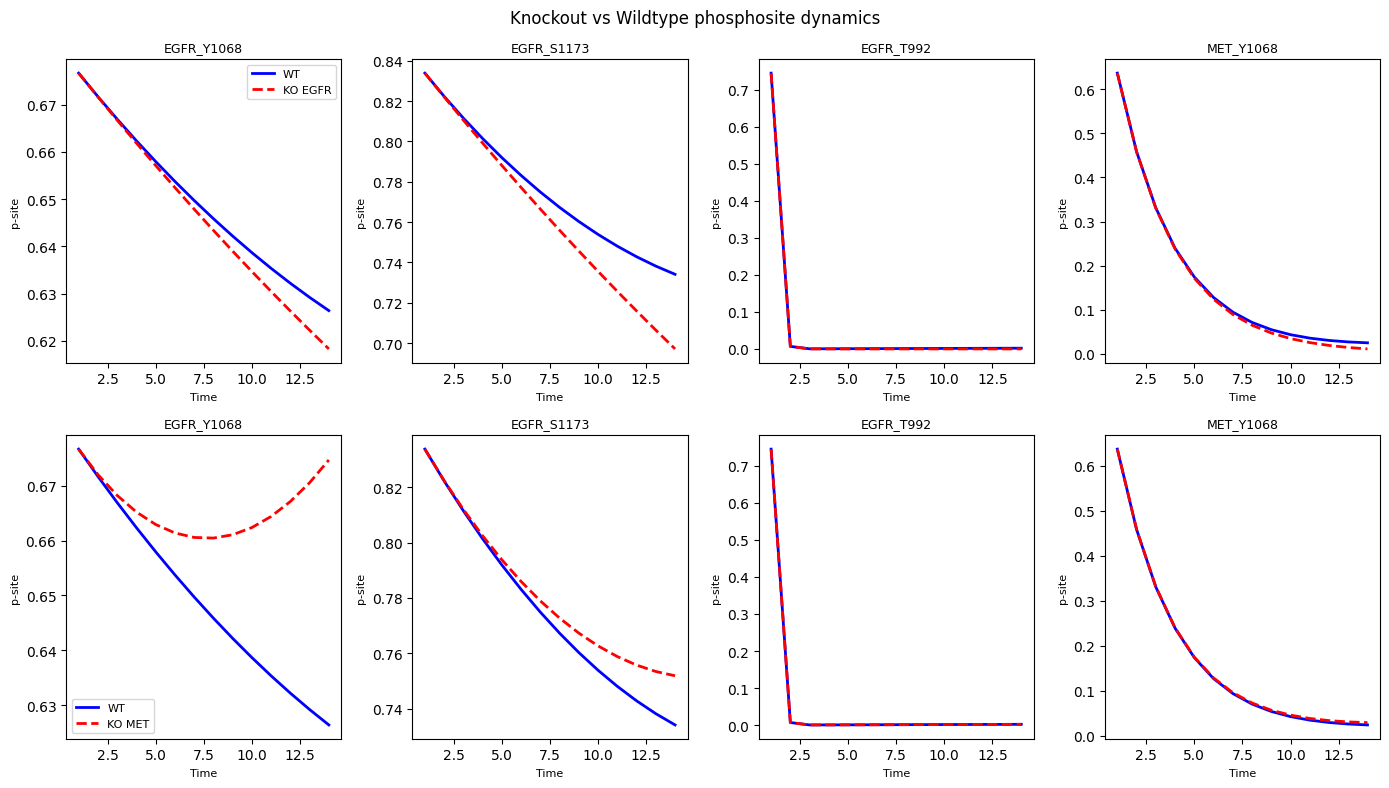

Saved: 14_knockout_simulations.png


In [9]:
# Wildtype reference trajectories (P_sim already computed above)
fig, axes = plt.subplots(M, min(4, N), figsize=(14, 4 * M), squeeze=False)

for ki, kin_name in enumerate(kinases):
    K_ko = K_site_kin.copy()
    K_ko[:, ki] = 0.0
    R_ko = row_normalize(K_ko.T)
    s_prod_ko = make_s_prod_fn(t_protein=t_phos, Y_data=P_scaled,
                               R_kin_site=R_ko, kin_to_prot_idx=kin_to_prot_idx, K=K, M=M)
    P_ko, A_ko, _, _ = simulate(
        t_arr=t_phos, P_data0=P_scaled, A_data0=A_scaled,
        theta=theta_best, Cg=Cg, Cl=Cl,
        site_prot_idx=site_prot_idx, K_site_kin=K_ko, R=R_ko,
        L_alpha=L_alpha, kin_to_prot_idx=kin_to_prot_idx,
        receptor_mask_prot=receptor_mask_prot, receptor_mask_kin=receptor_mask_kin,
        mechanism='dist', full_output=True,
        k_act_fn=k_act_fn, s_prod_fn=s_prod_ko,
    )
    for si in range(min(4, N)):
        ax = axes[ki][si]
        ax.plot(t_phos, P_sim[si],  'b-',  lw=2, label='WT')
        ax.plot(t_phos, P_ko[si],   'r--', lw=2, label=f'KO {kin_name}')
        ax.set_title(sites[si], fontsize=9)
        ax.set_xlabel('Time', fontsize=8);  ax.set_ylabel('p-site', fontsize=8)
        if si == 0:
            ax.legend(fontsize=8)

plt.suptitle('Knockout vs Wildtype phosphosite dynamics', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '14_knockout_simulations.png', dpi=120)
plt.show()
print('Saved: 14_knockout_simulations.png')

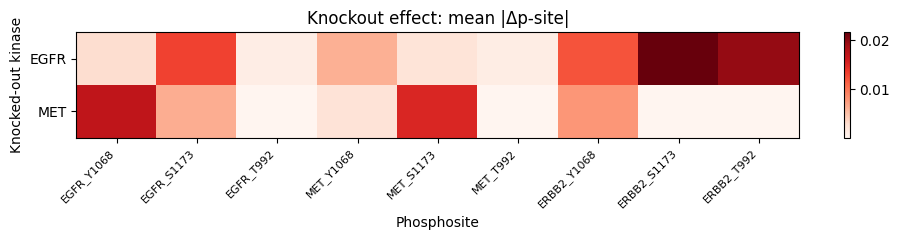

Saved: 14_knockout_effect_heatmap.png


In [10]:
# Knockout effect heatmap: mean |Δp-site| per (kinase, site)
ko_effects = np.zeros((M, N))
for ki, kin_name in enumerate(kinases):
    K_ko = K_site_kin.copy();  K_ko[:, ki] = 0.0
    R_ko = row_normalize(K_ko.T)
    s_prod_ko = make_s_prod_fn(t_protein=t_phos, Y_data=P_scaled,
                               R_kin_site=R_ko, kin_to_prot_idx=kin_to_prot_idx, K=K, M=M)
    P_ko, *_ = simulate(
        t_arr=t_phos, P_data0=P_scaled, A_data0=A_scaled,
        theta=theta_best, Cg=Cg, Cl=Cl,
        site_prot_idx=site_prot_idx, K_site_kin=K_ko, R=R_ko,
        L_alpha=L_alpha, kin_to_prot_idx=kin_to_prot_idx,
        receptor_mask_prot=receptor_mask_prot, receptor_mask_kin=receptor_mask_kin,
        mechanism='dist', full_output=True,
        k_act_fn=k_act_fn, s_prod_fn=s_prod_ko,
    )
    ko_effects[ki] = np.abs(P_ko - P_sim).mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 2.5))
im = ax.imshow(ko_effects, aspect='auto', cmap='Reds')
ax.set_yticks(range(M));  ax.set_yticklabels(kinases)
ax.set_xticks(range(N));  ax.set_xticklabels(sites, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Phosphosite');  ax.set_ylabel('Knocked-out kinase')
ax.set_title('Knockout effect: mean |Δp-site|')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '14_knockout_effect_heatmap.png', dpi=120)
plt.show()
print('Saved: 14_knockout_effect_heatmap.png')

## 5. Summary

| Analysis | Key output | Config flag |
|----------|-----------|-------------|
| Sensitivity | `sensitivity_heatmap.png` | `run_sensitivity = true` |
| Steady state | `steady_state_results.tsv` + plots | `run_steadystate = true` |
| Knockouts | knockout plots + effect heatmap | `run_knockouts = true` |